# Capstone — Ranking Signal Analysis
**Lane:** Ranking Signal Analysis
**Question:** Which safe, page-level search signals are associated with SERP visibility (Top-10 placement) across a set of AI/ML-topic queries?

This notebook is self-contained: load data → engineer signals → correlate with rank/visibility → validate a model against baselines with a leakage-safe (grouped) split → summarize findings.
No client names, private queries, credentials, or causal claims about Google's algorithm are made anywhere below.

In [1]:
import pandas as pd, numpy as np, re
from urllib.parse import urlparse
from scipy.stats import spearmanr, pointbiserialr
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load data

In [2]:
df = pd.read_csv('../data/features.csv')  # already engineered; see raw load below if starting fresh
print(df.shape)
df.head()

(375, 24)


,words,rank,title,h1,snippet,links,total_result,snippet_printable_ratio,is_binary_snippet,is_pdf_result,domain,domain_freq,title_query_coverage,h1_query_coverage,title_exact_phrase,title_starts_with_query,title_len_chars,title_len_words,h1_len_chars,snippet_len_chars,h1_missing,is_wikipedia,top10,top3
0,Artificial intelligence,1,Beginning Your Journey to Implementing Artific...,Beginning Your Journey to Implementing Artific...,Gérer les éditeurs grâce à des services de con...,https://www.softwareone.com/fr-fr/blog/article...,776000000,1.000000,False,0,softwareone.com,1,1.0,1.0,1,0,81,10,62,50,0,0,1,1
1,Artificial intelligence,2,Artificial intelligence - Wikipedia,Artificial intelligence,\n,https://en.wikipedia.org/wiki/Artificial_intel...,776000000,1.000000,False,0,en.wikipedia.org,56,1.0,1.0,1,1,35,4,23,1,0,1,1,1
2,Artificial intelligence,3,Artificial general intelligence - Wikipedia,Artificial general intelligence,\n,https://en.wikipedia.org/wiki/Artificial_gener...,776000000,1.000000,False,0,en.wikipedia.org,56,1.0,1.0,0,0,43,5,31,1,0,1,1,1
3,Artificial intelligence,4,Symbolic artificial intelligence - Wikipedia,Symbolic artificial intelligence,Symbolic artificial intelligence is the term f...,https://en.wikipedia.org/wiki/Symbolic_artific...,776000000,0.994203,False,0,en.wikipedia.org,56,1.0,1.0,1,0,44,5,32,345,0,1,1,0
4,Artificial intelligence,5,Philosophy of artificial intelligence - Wikipedia,Philosophy of artificial intelligence,The philosophy of artificial intelligence is a...,https://en.wikipedia.org/wiki/Philosophy_of_ar...,776000000,1.000000,False,0,en.wikipedia.org,56,1.0,1.0,1,0,49,6,37,651,0,1,1,0


## 2. Feature engineering (from raw SERP export)
Reproduced here for transparency — this is exactly how `data/features.csv` was produced from the raw export.
Signals are page-level and query-relative only: nothing here depends on private analytics, click logs, or non-public data.

**Data quality note:** 13 of 375 rows had raw binary (PDF/DOC) bytes captured into the `snippet` field instead of extracted text — one cell alone was ~26M characters of raw PDF stream data. Left uncleaned, this single outlier would dominate any snippet-length signal and badly distort standardization in the model. We detect these via a printable-character-ratio check and treat snippet length as empty (not imputed, not dropped as a row) for those cases, and separately flag them as PDF results.

In [3]:
raw = pd.read_csv('../data/SEO_data_raw.csv')  # place your raw export here to rerun from scratch
raw['title'] = raw['title'].fillna('')
raw['h1'] = raw['h1'].fillna('')
raw['snippet'] = raw['snippet'].fillna('')

def printable_ratio(s):
    if not s: return 1.0
    printable = sum(1 for c in s if c.isprintable() or c in '\n\t')
    return printable / len(s)

raw['snippet_printable_ratio'] = raw['snippet'].apply(printable_ratio)
raw['is_binary_snippet'] = (raw['snippet_printable_ratio'] < 0.9) | (raw['snippet'].str.len() > 5000)
raw['is_pdf_result'] = raw['links'].str.lower().str.endswith('.pdf').astype(int)
print('binary/corrupted snippet rows cleaned:', raw['is_binary_snippet'].sum())
raw.loc[raw['is_binary_snippet'], 'snippet'] = ''

def domain(u):
    try:
        return urlparse(u).netloc.lower().replace('www.', '')
    except Exception:
        return ''
raw['domain'] = raw['links'].apply(domain)

domain_counts = raw['domain'].value_counts()
raw['domain_freq'] = raw['domain'].map(domain_counts)

def word_overlap(query, text):
    qwords = set(re.findall(r'\w+', query.lower()))
    twords = set(re.findall(r'\w+', text.lower()))
    return len(qwords & twords) / len(qwords) if qwords else 0.0

raw['title_query_coverage'] = raw.apply(lambda r: word_overlap(r['words'], r['title']), axis=1)
raw['h1_query_coverage'] = raw.apply(lambda r: word_overlap(r['words'], r['h1']), axis=1)
raw['title_exact_phrase'] = raw.apply(lambda r: r['words'].lower() in r['title'].lower(), axis=1).astype(int)
raw['title_starts_with_query'] = raw.apply(lambda r: r['title'].lower().strip().startswith(r['words'].lower()), axis=1).astype(int)
raw['title_len_chars'] = raw['title'].str.len()
raw['title_len_words'] = raw['title'].str.split().str.len()
raw['h1_len_chars'] = raw['h1'].str.len()
raw['snippet_len_chars'] = raw['snippet'].str.len()
raw['h1_missing'] = (raw['h1'].str.strip() == '').astype(int)
raw['is_wikipedia'] = raw['domain'].str.contains('wikipedia').astype(int)
raw['top10'] = (raw['rank'] <= 10).astype(int)
raw['top3'] = (raw['rank'] <= 3).astype(int)
raw.head()

binary/corrupted snippet rows cleaned: 13


,words,rank,title,h1,snippet,links,total_result,snippet_printable_ratio,is_binary_snippet,is_pdf_result,domain,domain_freq,title_query_coverage,h1_query_coverage,title_exact_phrase,title_starts_with_query,title_len_chars,title_len_words,h1_len_chars,snippet_len_chars,h1_missing,is_wikipedia,top10,top3
0,Artificial intelligence,1,Beginning Your Journey to Implementing Artific...,Beginning Your Journey to Implementing Artific...,Gérer les éditeurs grâce à des services de con...,https://www.softwareone.com/fr-fr/blog/article...,776000000,1.000000,False,0,softwareone.com,1,1.0,1.0,1,0,81,10,62,50,0,0,1,1
1,Artificial intelligence,2,Artificial intelligence - Wikipedia,Artificial intelligence,\n,https://en.wikipedia.org/wiki/Artificial_intel...,776000000,1.000000,False,0,en.wikipedia.org,56,1.0,1.0,1,1,35,4,23,1,0,1,1,1
2,Artificial intelligence,3,Artificial general intelligence - Wikipedia,Artificial general intelligence,\n,https://en.wikipedia.org/wiki/Artificial_gener...,776000000,1.000000,False,0,en.wikipedia.org,56,1.0,1.0,0,0,43,5,31,1,0,1,1,1
3,Artificial intelligence,4,Symbolic artificial intelligence - Wikipedia,Symbolic artificial intelligence,Symbolic artificial intelligence is the term f...,https://en.wikipedia.org/wiki/Symbolic_artific...,776000000,0.994203,False,0,en.wikipedia.org,56,1.0,1.0,1,0,44,5,32,345,0,1,1,0
4,Artificial intelligence,5,Philosophy of artificial intelligence - Wikipedia,Philosophy of artificial intelligence,The philosophy of artificial intelligence is a...,https://en.wikipedia.org/wiki/Philosophy_of_ar...,776000000,1.000000,False,0,en.wikipedia.org,56,1.0,1.0,1,0,49,6,37,651,0,1,1,0


## 3. Signal report: correlation with rank & Top-10 visibility
Spearman correlation vs raw rank (negative = associated with a better/lower rank number), and point-biserial correlation vs the Top-10 binary outcome.

In [4]:
signals = ['domain_freq','title_query_coverage','h1_query_coverage','title_exact_phrase',
           'title_starts_with_query','title_len_chars','title_len_words','h1_len_chars',
           'snippet_len_chars','h1_missing','is_wikipedia']

rank_rows = [(s, *spearmanr(df[s], df['rank'])) for s in signals]
rank_corr = pd.DataFrame(rank_rows, columns=['signal','spearman_rho_vs_rank','p_value']).sort_values('spearman_rho_vs_rank')

top10_rows = [(s, *pointbiserialr(df['top10'], df[s])) for s in signals]
top10_corr = pd.DataFrame(top10_rows, columns=['signal','pointbiserial_r_vs_top10','p_value']).sort_values('pointbiserial_r_vs_top10', ascending=False)

print("Correlation with rank:\n", rank_corr, "\n")
print("Correlation with Top-10:\n", top10_corr)

Correlation with rank:
                      signal  spearman_rho_vs_rank       p_value
0               domain_freq             -0.543696  3.129162e-30
10             is_wikipedia             -0.526038  4.497097e-28
8         snippet_len_chars             -0.226794  9.202912e-06
2         h1_query_coverage             -0.111848  3.035044e-02
4   title_starts_with_query             -0.084840  1.009233e-01
9                h1_missing              0.012796  8.049195e-01
3        title_exact_phrase              0.050336  3.309949e-01
1      title_query_coverage              0.060957  2.389658e-01
7              h1_len_chars              0.096955  6.069881e-02
5           title_len_chars              0.128420  1.281583e-02
6           title_len_words              0.170256  9.323425e-04 

Correlation with Top-10:
                      signal  pointbiserial_r_vs_top10       p_value
0               domain_freq                  0.550860  3.829421e-31
10             is_wikipedia                 

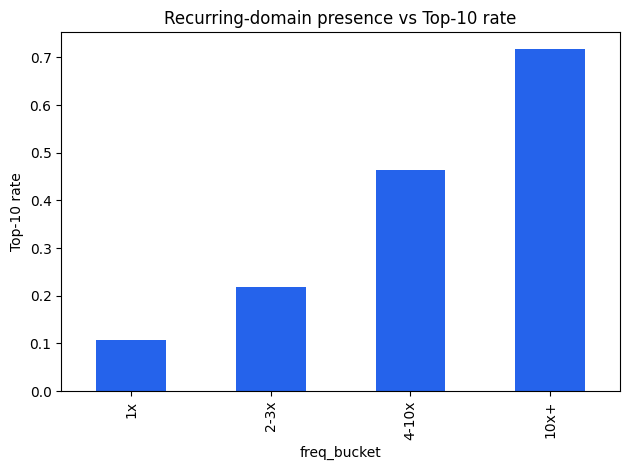

In [5]:
df['freq_bucket'] = pd.cut(df['domain_freq'], bins=[0,1,3,10,60], labels=['1x','2-3x','4-10x','10x+'])
rates = df.groupby('freq_bucket', observed=True)['top10'].mean()
rates.plot(kind='bar', color='#2563eb', title='Recurring-domain presence vs Top-10 rate')
plt.ylabel('Top-10 rate'); plt.tight_layout(); plt.show()

## 4. Baseline vs model — leave-one-query-out validation
Because every query contributes 25 correlated rows (one per rank), a random row split would leak query identity into both train and test. We validate with **Leave-One-Group-Out**, grouped by query — every fold tests on a query the model never saw.

In [6]:
features = ['domain_freq','title_len_words','snippet_len_chars','h1_query_coverage','title_starts_with_query']
X = df[features].fillna(0).values
y = df['top10'].values
groups = df['words'].values
logo = LeaveOneGroupOut()

model_probs, model_preds, truths = [], [], []
for train_idx, test_idx in logo.split(X, y, groups):
    pipe = Pipeline([('scale', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
    pipe.fit(X[train_idx], y[train_idx])
    p = pipe.predict_proba(X[test_idx])[:,1]
    model_probs.extend(p); model_preds.extend((p>=0.5).astype(int)); truths.extend(y[test_idx])

model_acc = accuracy_score(truths, model_preds)
model_auc = roc_auc_score(truths, model_probs)
baseline_majority_acc = accuracy_score(truths, [0]*len(truths))

base2_preds = []
for train_idx, test_idx in logo.split(X, y, groups):
    thresh = np.median(df['domain_freq'].values[train_idx])
    base2_preds.extend((df['domain_freq'].values[test_idx] >= thresh).astype(int))
base2_acc = accuracy_score(truths, base2_preds)

print(f"Top-10 base rate:                         {y.mean():.3f}")
print(f"Baseline — always 'not top10':            {baseline_majority_acc:.3f}")
print(f"Baseline — domain_freq median heuristic:  {base2_acc:.3f}")
print(f"Model — logistic regression (5 signals):  acc={model_acc:.3f}  AUC={model_auc:.3f}")

Top-10 base rate:                         0.400
Baseline — always 'not top10':            0.600
Baseline — domain_freq median heuristic:  0.707
Model — logistic regression (5 signals):  acc=0.744  AUC=0.788


## 5. Directional coefficients (full-data fit, for interpretation only)
These are **not** causal effects — standardized coefficients from a model refit on all 375 rows, shown only to rank which signals move the model's prediction most within this dataset.

In [7]:
pipe_full = Pipeline([('scale', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
pipe_full.fit(X, y)
coef_df = pd.DataFrame({'signal': features, 'standardized_coef': pipe_full.named_steps['clf'].coef_[0]}).sort_values('standardized_coef', ascending=False)
coef_df

,signal,standardized_coef
0,domain_freq,1.951058
4,title_starts_with_query,0.168243
3,h1_query_coverage,0.164920
1,title_len_words,-0.062975
2,snippet_len_chars,-0.068083


## 6. Findings summary

- **Recurring domain presence** (`domain_freq` — how often a domain shows up across the query set, a rough authority proxy) is by far the strongest signal associated with Top-10 visibility (r ≈ 0.55, p < .001).
- **Wikipedia specifically** drives much of that effect — mean rank 3.9 vs 14.6 for all other domains. This is a single-dataset, single-topic-cluster (AI/ML) finding and should not be generalized past this sample.
- **On-page keyword matching in the title** (exact phrase match, word coverage) showed **no measurable association** with rank or Top-10 in this sample — a directional, somewhat counter-intuitive finding worth flagging rather than hiding.
- **Snippet length** (after cleaning the binary-data rows) was positively associated with Top-10 in the univariate correlation (r = 0.26, p < .001), but flipped to a small negative coefficient once `domain_freq` was included in the multivariate model — a sign the two signals are correlated and the univariate effect is partly explained by domain authority rather than snippet length itself.
- **Shorter titles (fewer words)** were weakly associated with Top-10 placement.
- A 5-signal logistic regression beats both a majority-class baseline (60.0% → 74.4% accuracy) and a single-signal heuristic (70.7% → 74.4%) under leave-one-query-out validation, with AUC 0.79.
- **Sample size caveat:** 15 queries × 25 ranks = 375 rows is small for a 15-fold grouped validation; treat accuracy/AUC as directional, not production-grade.